In [36]:
from google.colab import drive
drive.mount("/content/drive")

import os
os.chdir('/content/drive/MyDrive/Stock/交易策略/RSI')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
! pip install backtrader

# 黃金交叉和死亡交叉的買入賣出

In [38]:
import pandas as pd
import numpy as np
import backtrader as bt
from IPython.display import display
import matplotlib.pyplot as plt

class PandasData(bt.feeds.PandasData):
    lines = ('RSI_7', 'RSI_14')
    params = (
        ('datetime', None),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),
        ('RSI_7', 'RSI_7'),
        ('RSI_14', 'RSI_14'),
    )

class TaiwanStockCommission(bt.CommissionInfo):
    params = (
        ("commission", 0.001425),
        ("tax", 0.003),
    )
    def _getcommission(self, size, price, pseudoexec):
        value = abs(size) * price
        commission = value * self.p.commission
        if size < 0:
            commission += value * self.p.tax
        return commission

class AllInSizer(bt.Sizer):
    params = (("reserve", 0.05),("lot_size", 1000),)
    def _getsizing(self, comminfo, cash, data, isbuy):
        if isbuy:
            cash *= (1 - self.p.reserve)
            price = data.close[0]
            cost_per_share = price * (1 + comminfo.p.commission)
            shares = int(cash / cost_per_share)
            if shares <= 0:
              return 0

            whole_lot = (shares // self.p.lot_size) * self.p.lot_size
            if whole_lot >= self.p.lot_size:
              return whole_lot

            return shares

        return self.broker.getposition(data).size

class RSIStrategy(bt.Strategy):
    params = dict(stop_loss=0.10)

    def __init__(self):
        self.RSI_7 = self.data.RSI_7
        self.RSI_14 = self.data.RSI_14
        self.cross = bt.ind.CrossOver(self.RSI_7, self.RSI_14)
        self.order = None
        self.buyprice = None
        self.trades_history = []

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status == order.Completed:
            date = self.data.datetime.date(0)
            exec_price = order.executed.price
            exec_size = abs(order.executed.size)
            exec_value = exec_price * exec_size

            comminfo = order.comminfo
            commission = exec_value * comminfo.p.commission
            tax = (exec_value * comminfo.p.tax) if order.issell() else 0.0

            current_value = self.broker.getvalue()
            pnl_pct = (current_value / 1_000_000 - 1) * 100

            action = "買入" if order.isbuy() else "賣出"
            if order.isbuy():
                self.buyprice = exec_price

            self.trades_history.append({
                "交易日期": date,
                "買賣別": action,
                "成交價": round(exec_price, 2),
                "成交量(股)": exec_size,
                "交易金額": round(exec_value, 2),
                "手續費": round(commission, 2),
                "證交稅": round(tax, 2),
                "總資產": round(current_value, 2),
                "目前報酬率(%)": round(pnl_pct, 2)
            })
            # 關閉單筆印出以保持版面整潔，需要可取消註解
            # print(f"{date} {action} | 價格:{exec_price:.2f} | 成交量:{exec_size} | 手續費:{commission:.0f} | 證交稅:{tax:.0f}")

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            print(f"{self.data.datetime.date(0)} 交易失敗 : {order.getstatusname()}")

        self.order = None

    def next(self):
        if self.order:
            return
        if self.position:
            loss = (self.data.close[0] - self.buyprice) / self.buyprice
            if loss <= -self.p.stop_loss:
                # print(f"{self.data.datetime.date(0)}停損觸發")
                self.order = self.close()
                return
            if self.cross < 0:
                # print(f"{self.data.datetime.date(0)}RSI死亡交叉")
                self.order = self.close()
                return
        else:
            if self.cross > 0:
                # print(f"{self.data.datetime.date(0)}RSI黃金交叉")
                self.order = self.buy()

    def stop(self):
        if self.position:
            # print(f"回測結束，強制結算持股：{self.position.size}股")
            self.close()

# 執行回測
def run_backtest(ticker):
    print("\n" + "="*50)
    print(f" 回測標的：{ticker}")
    print("="*50)

    # 讀取資料
    try:
        df = pd.read_csv(f"{ticker}_Cal.csv")
    except FileNotFoundError:
        print(f"找不到檔案：{ticker}_Cal.csv，跳過此標的。")
        return

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    df_bt = df[['date', 'open', 'max', 'min', 'close', 'RSI_7', 'RSI_14', 'Trading_Volume']].copy()
    df_bt = df_bt.rename(columns={"max": "high", "min": "low", "Trading_Volume": "volume"})
    df_bt = df_bt.dropna().reset_index(drop=True)
    df_bt = df_bt.set_index("date")

    # Cerebro
    cerebro = bt.Cerebro()
    cerebro.addstrategy(RSIStrategy)
    cerebro.addsizer(AllInSizer, reserve=0.05)

    data = PandasData(dataname=df_bt)
    cerebro.adddata(data)
    cerebro.broker.setcash(1_000_000)

    comminfo = TaiwanStockCommission()
    cerebro.broker.addcommissioninfo(comminfo)

    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.015, annualize=True, timeframe=bt.TimeFrame.Days)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

    # 執行回測
    results = cerebro.run()
    strat = results[0]

    # 整理表格
    df_trades = pd.DataFrame(strat.trades_history)
    final_val = cerebro.broker.getvalue()
    pnl_pct = (final_val / 1_000_000 - 1) * 100

    if strat.position:
        last_date = strat.data.datetime.date(0)
        pos_size = strat.position.size
        close_price = strat.data.close[0]
        unrealized_value = pos_size * close_price

        unrealized_row = pd.DataFrame([{
            "交易日期": last_date, "買賣別": "結算",
            "成交價": round(close_price, 2), "成交量(股)": pos_size,
            "交易金額": round(unrealized_value, 2), "手續費": 0.0, "證交稅": 0.0,
            "總資產": round(final_val, 2), "目前報酬率(%)": round(pnl_pct, 2)
        }])
        df_trades = pd.concat([df_trades, unrealized_row], ignore_index=True)

    # 輸出 CSV
    df_trades.to_csv(f'{ticker}_df_trades.csv', index=False)

    # 績效指標計算
    mdd = strat.analyzers.drawdown.get_analysis()['max']['drawdown']
    sharpe_info = strat.analyzers.sharpe.get_analysis()
    sharpe = sharpe_info.get('sharperatio', None)

    trade_pnls = []
    raw_trades = df_trades[df_trades['買賣別'] != '結算'].copy()
    buy_record = None
    for _, row in df_trades.iterrows():
        if row['買賣別'] == '買入':
            buy_record = row
        elif row['買賣別'] in ['賣出', '結算'] and buy_record is not None:
            cost = buy_record['交易金額'] + buy_record['手續費']
            revenue = row['交易金額'] - row['手續費'] - row['證交稅']
            pnl = revenue - cost
            trade_pnls.append(pnl)
            buy_record = None

    trade_pnls = np.array(trade_pnls)
    if len(trade_pnls) > 0:
        wins = trade_pnls[trade_pnls > 0]
        losses = trade_pnls[trade_pnls < 0]
        win_rate = (len(wins) / len(trade_pnls)) * 100
        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = abs(np.mean(losses)) if len(losses) > 0 else 0
        profit_factor = (avg_win / avg_loss) if avg_loss != 0 else np.nan
    else:
        win_rate = profit_factor = 0.0

    print(f"最終資金：{final_val:,.2f} 元")
    print(f"總報酬率：{pnl_pct:.2f} %")
    print(f"最大回撤 (MDD)：{mdd:.2f} %")
    print(f"夏普比率(Sharpe)：{sharpe:.2f}" if sharpe is not None else "夏普比率(Sharpe)：無法計算 (無交易)")
    print(f"總交易次數：{len(trade_pnls)} 次")
    print(f"勝率：{win_rate:.2f} %")
    print(f"賺賠比：{profit_factor:.2f}")

    print("\n=== 交易紀錄表 ===")
    display(df_trades)

    # 繪圖
    plt.rcParams['figure.figsize'] = [20, 12]
    plt.rcParams['figure.dpi'] = 150
    cerebro.plot(style="candlestick", iplot=False, heightp=0.5)
    plt.show()

    return {
        "標的": ticker,
        "交易策略": "RSI 黃金交叉／死亡交叉", #　交易策略有變動的話需更改
        "最終資金 (元)": round(final_val, 2),
        "總報酬率": round(pnl_pct, 2),
        "最大回撤 (MDD)": round(mdd, 2),
        "夏普比率": round(sharpe, 2) if sharpe is not None else np.nan,
        "總交易次數": len(trade_pnls),
        "勝率": round(win_rate, 2),
        "賺賠比": round(profit_factor, 2) if not np.isnan(profit_factor) else np.nan}

performance_summary = []
# 標的清單
stock_list = ["2330", "2313", "6257", "2382", "2317"]

for stock_id in stock_list:
    # run_backtest(stock_id)
    result = run_backtest(stock_id)

    if result is not None:
      performance_summary.append(result)
df_summary = pd.DataFrame(performance_summary)

# 依照報酬率排序
df_summary = df_summary.sort_values(by="總報酬率", ascending=False).reset_index(drop=True)

print("\n==============================")
print("      所有股票績效總表")
print("==============================")

display(df_summary)

df_summary.to_csv("RSI_Cross_Backtest_Performance.csv", index=False, encoding="utf-8-sig")

Output hidden; open in https://colab.research.google.com to view.

# RSI超買超賣


 回測標的：2330
最終資金：948,512.13 元
總報酬率：-5.15 %
最大回撤 (MDD)：34.24 %
夏普比率(Sharpe)：-0.08
總交易次數：25 次
勝率：64.00 %
賺賠比：0.52

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-02-04,買入,319.0,3000,957000.0,1363.73,0.00,1016636.28,1.66
1,2020-03-17,賣出,265.0,3000,795000.0,1132.88,2385.00,833118.40,-16.69
2,2020-03-18,買入,269.5,2000,539000.0,768.08,0.00,813350.32,-18.66
3,2020-04-20,賣出,308.0,2000,616000.0,877.80,1848.00,906624.52,-9.34
4,2020-10-30,買入,437.0,1000,437000.0,622.73,0.00,901001.80,-9.90
5,2020-11-10,賣出,452.0,1000,452000.0,644.10,1356.00,919001.70,-8.10
6,2021-03-25,買入,572.0,1000,572000.0,815.10,0.00,921186.60,-7.88
7,2021-06-16,賣出,608.0,1000,608000.0,866.40,1824.00,951496.20,-4.85
8,2021-06-23,買入,583.0,1000,583000.0,830.77,0.00,962665.42,-3.73
9,2021-07-15,賣出,613.0,1000,613000.0,873.52,1839.00,977952.90,-2.20


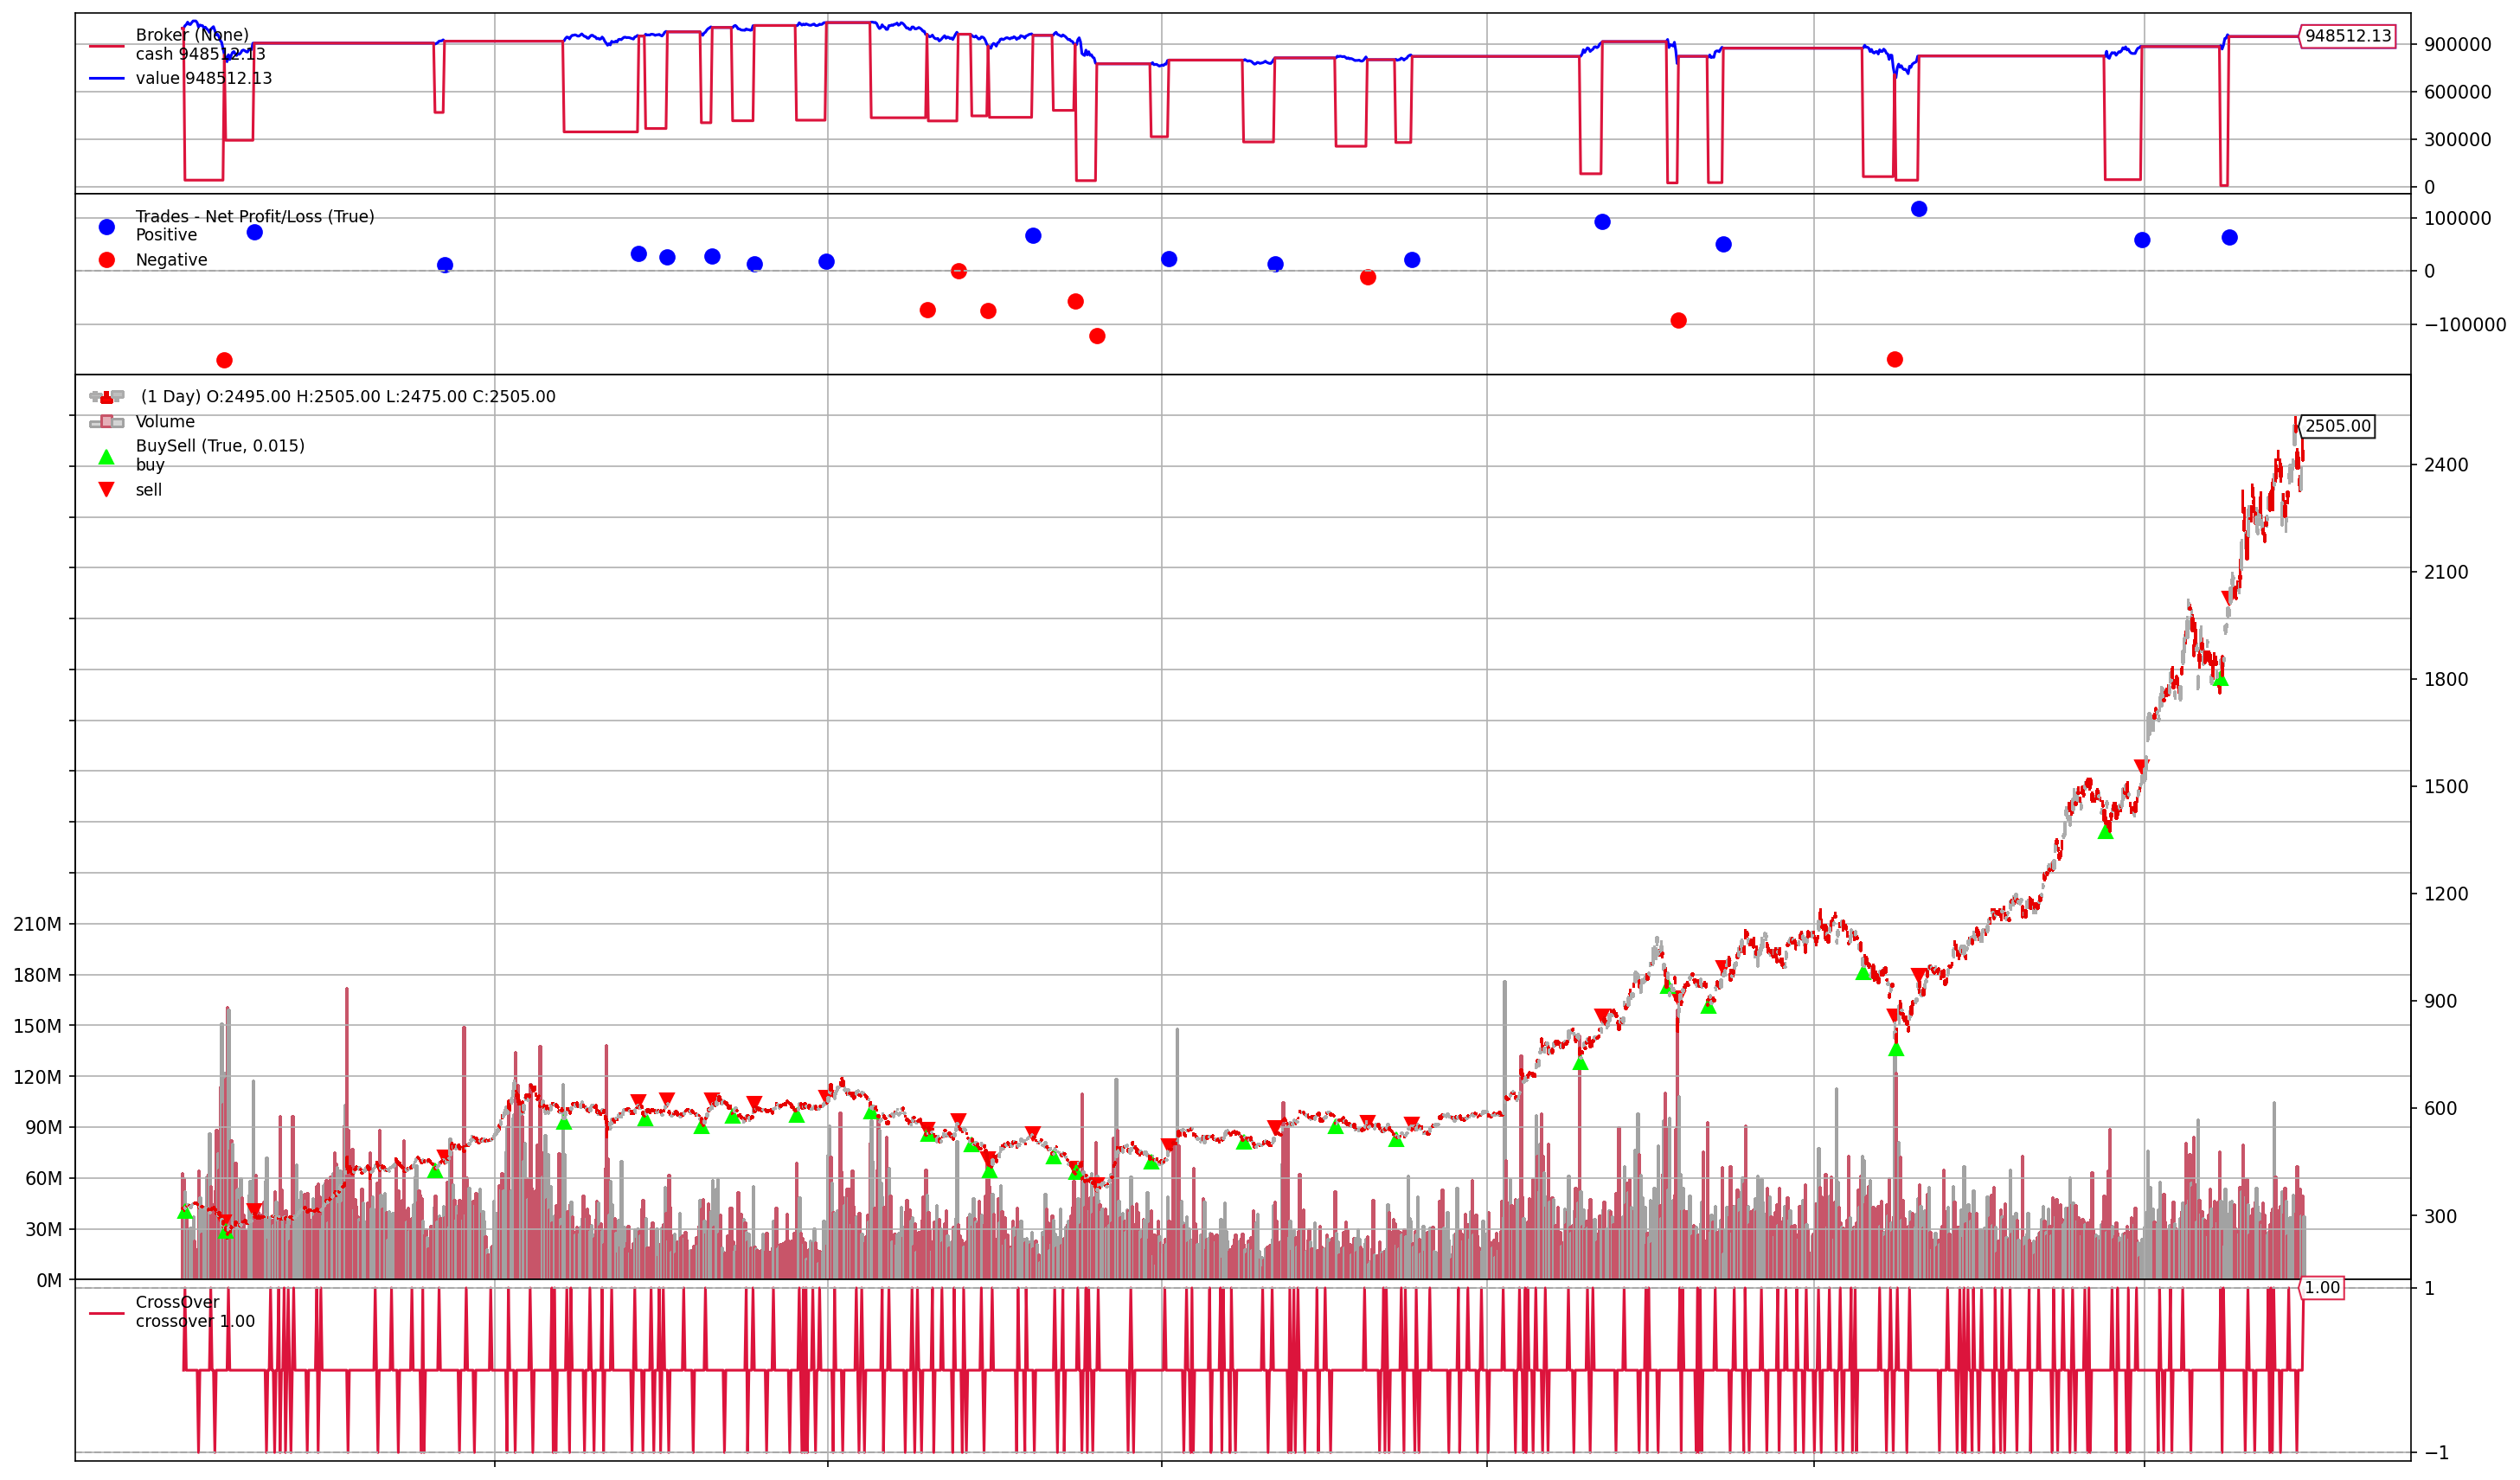


 回測標的：2313
2025-04-10 交易失敗 : Margin
最終資金：1,628,866.57 元
總報酬率：62.89 %
最大回撤 (MDD)：42.32 %
夏普比率(Sharpe)：0.38
總交易次數：29 次
勝率：62.07 %
賺賠比：0.90

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-02-04,買入,40.80,23000,938400.0,1337.22,0.00,1010162.78,1.02
1,2020-03-13,賣出,31.40,23000,722200.0,1029.13,2166.60,779267.05,-22.07
2,2020-03-16,買入,32.60,23000,749800.0,1068.47,0.00,711498.58,-28.85
3,2020-03-18,賣出,28.25,23000,649750.0,925.89,1949.25,675273.44,-32.47
4,2020-03-19,買入,25.50,24000,612000.0,872.10,0.00,626401.34,-37.36
5,2020-04-08,賣出,34.90,24000,837600.0,1193.58,2512.80,896294.96,-10.37
6,2020-08-21,買入,45.35,19000,861650.0,1227.85,0.00,891267.11,-10.87
7,2020-10-05,賣出,41.60,19000,790400.0,1126.32,2371.20,820319.59,-17.97
8,2020-12-14,買入,44.25,17000,752250.0,1071.96,0.00,817547.63,-18.25
9,2021-01-15,賣出,46.85,17000,796450.0,1134.94,2389.35,859923.34,-14.01


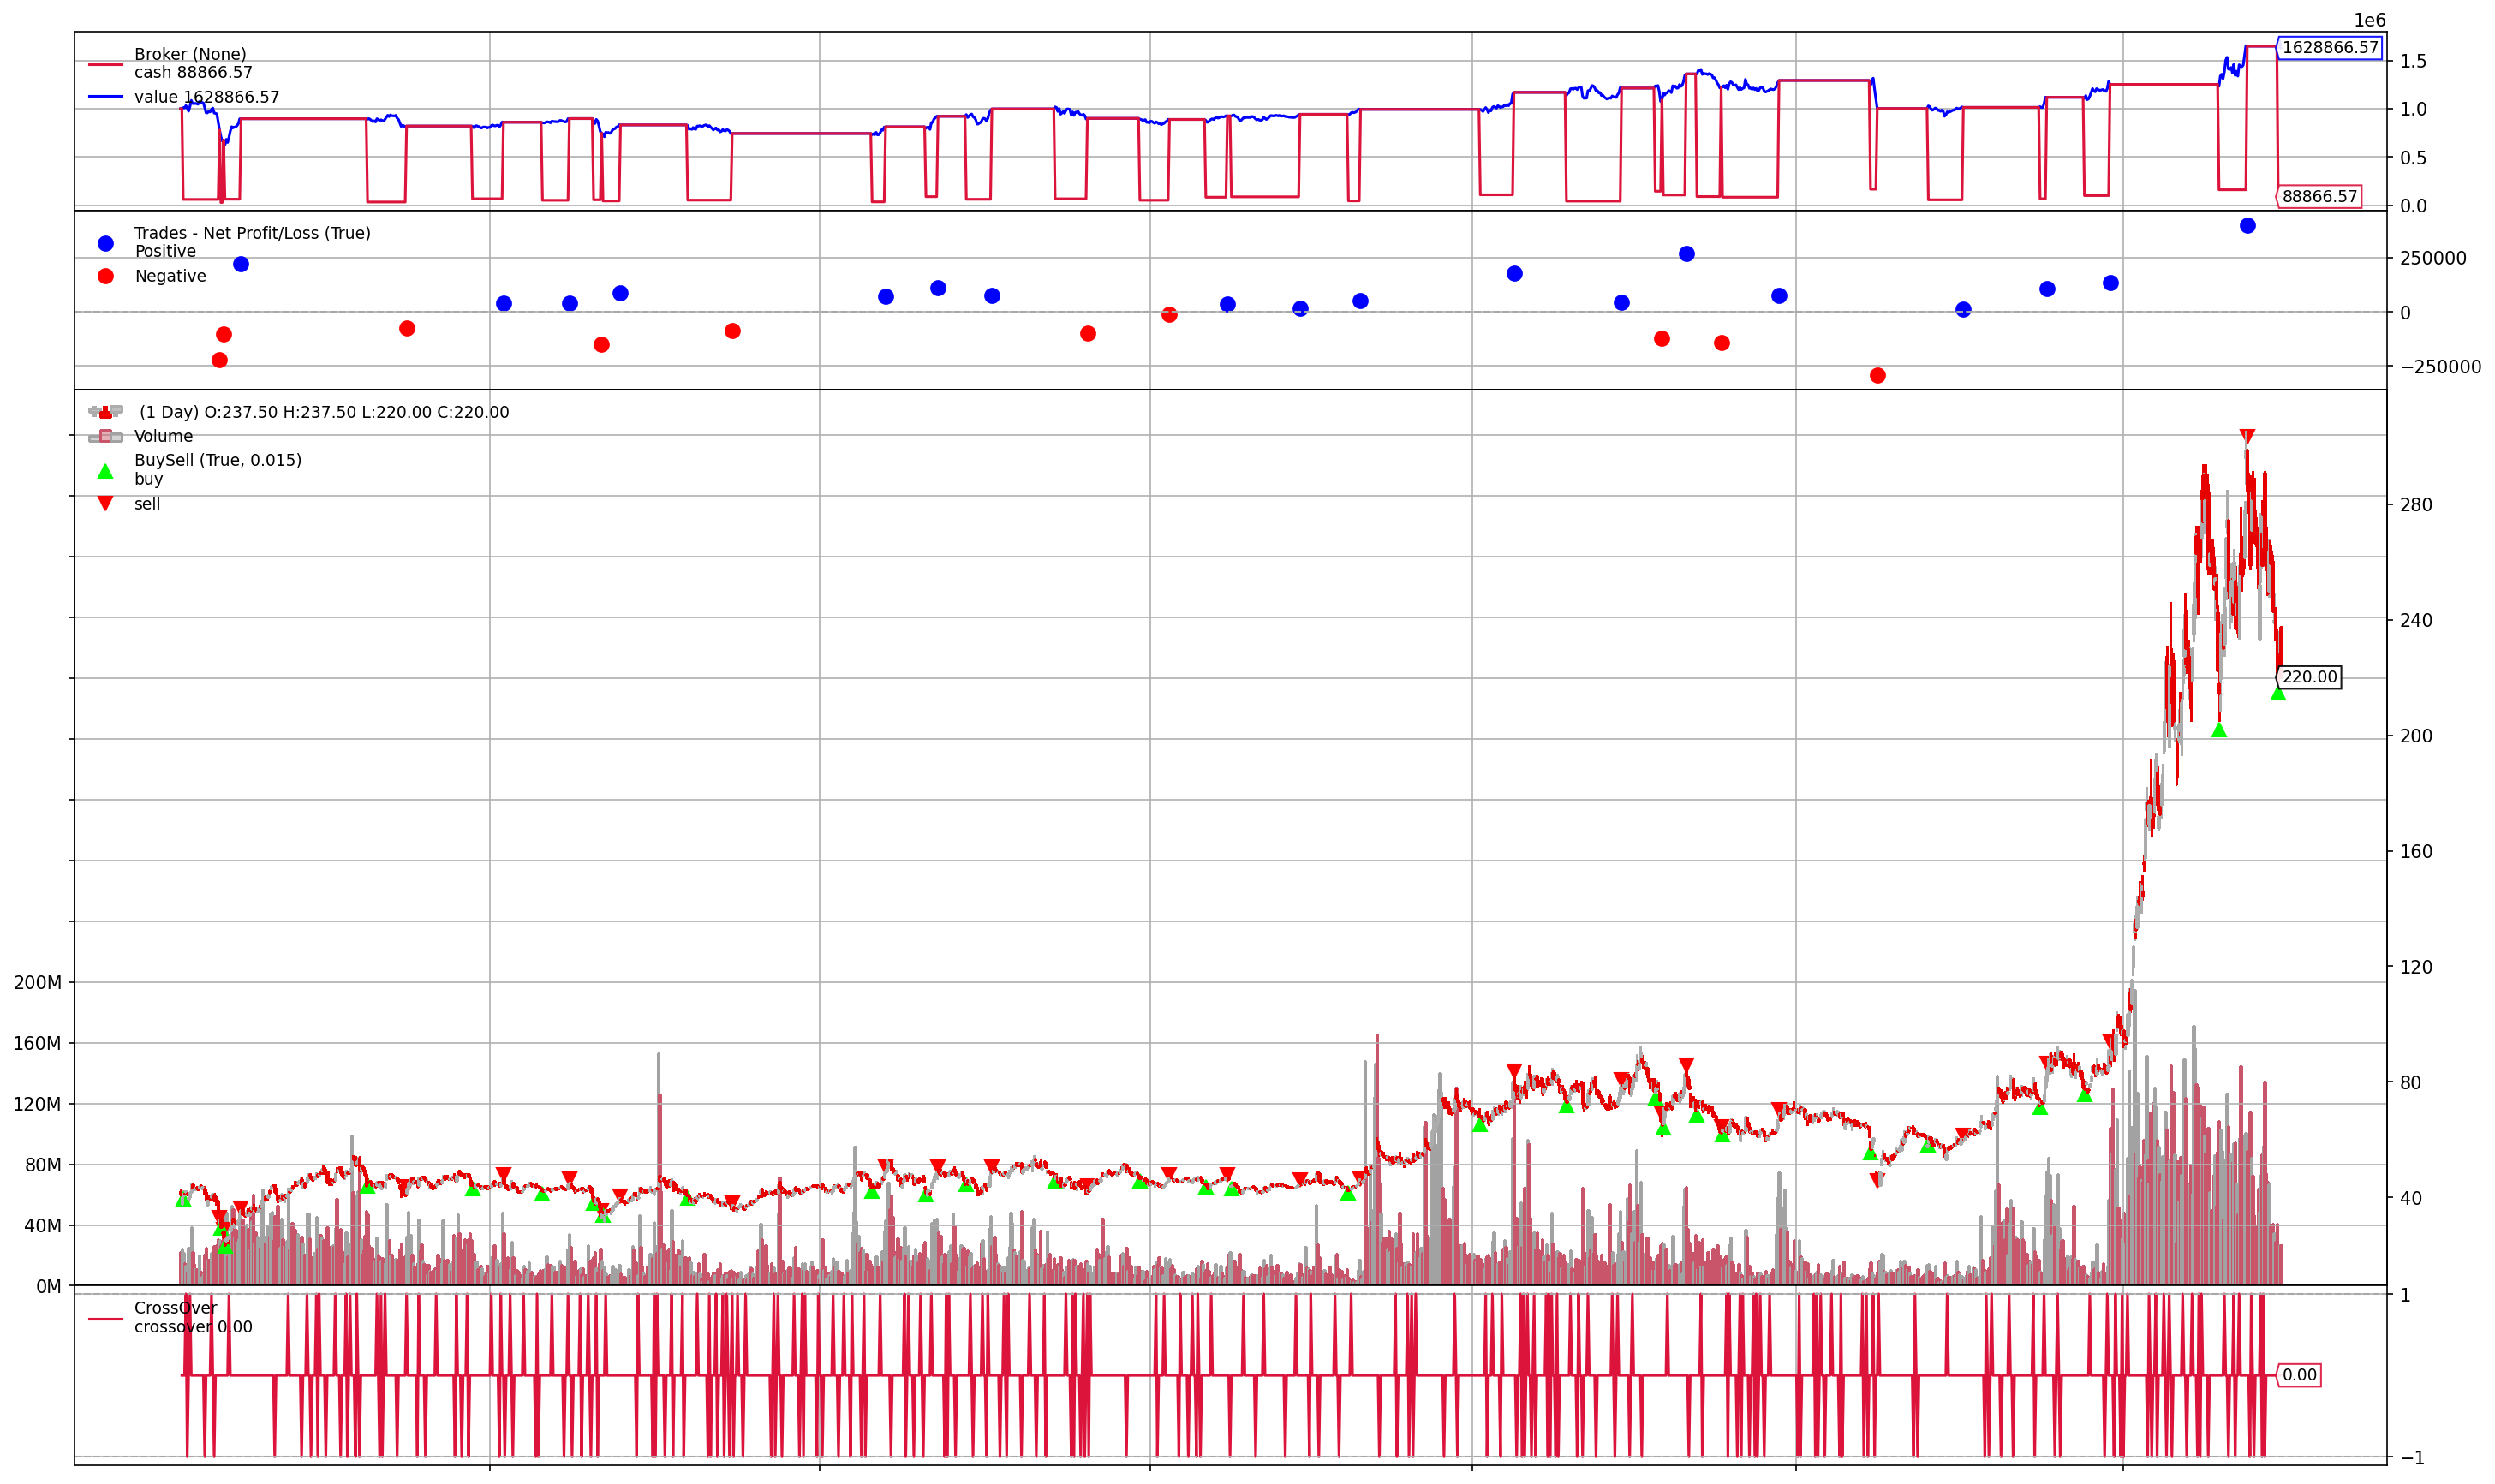


 回測標的：6257
最終資金：2,067,426.90 元
總報酬率：106.74 %
最大回撤 (MDD)：24.21 %
夏普比率(Sharpe)：0.71
總交易次數：23 次
勝率：73.91 %
賺賠比：0.91

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-02-04,買入,33.10,28000,926800.0,1320.69,0.0,1015479.31,1.55
1,2020-03-06,賣出,36.40,28000,1019200.0,1452.36,3057.6,1086569.35,8.66
2,2020-03-17,買入,31.00,32000,992000.0,1413.60,0.0,1086755.75,8.68
3,2020-03-20,賣出,28.60,32000,915200.0,1304.16,2745.6,1004305.99,0.43
4,2020-08-21,買入,39.30,24000,943200.0,1344.06,0.0,992161.93,-0.78
5,2020-11-10,賣出,40.50,24000,972000.0,1385.10,2916.0,1027460.83,2.75
6,2021-04-14,買入,50.30,19000,955700.0,1361.87,0.0,1018498.96,1.85
7,2021-04-29,賣出,57.50,19000,1092500.0,1556.81,3277.5,1158064.65,15.81
8,2021-05-13,買入,46.60,23000,1071800.0,1527.32,0.0,1184137.33,18.41
9,2021-06-07,賣出,54.40,23000,1251200.0,1782.96,3753.6,1330400.77,33.04


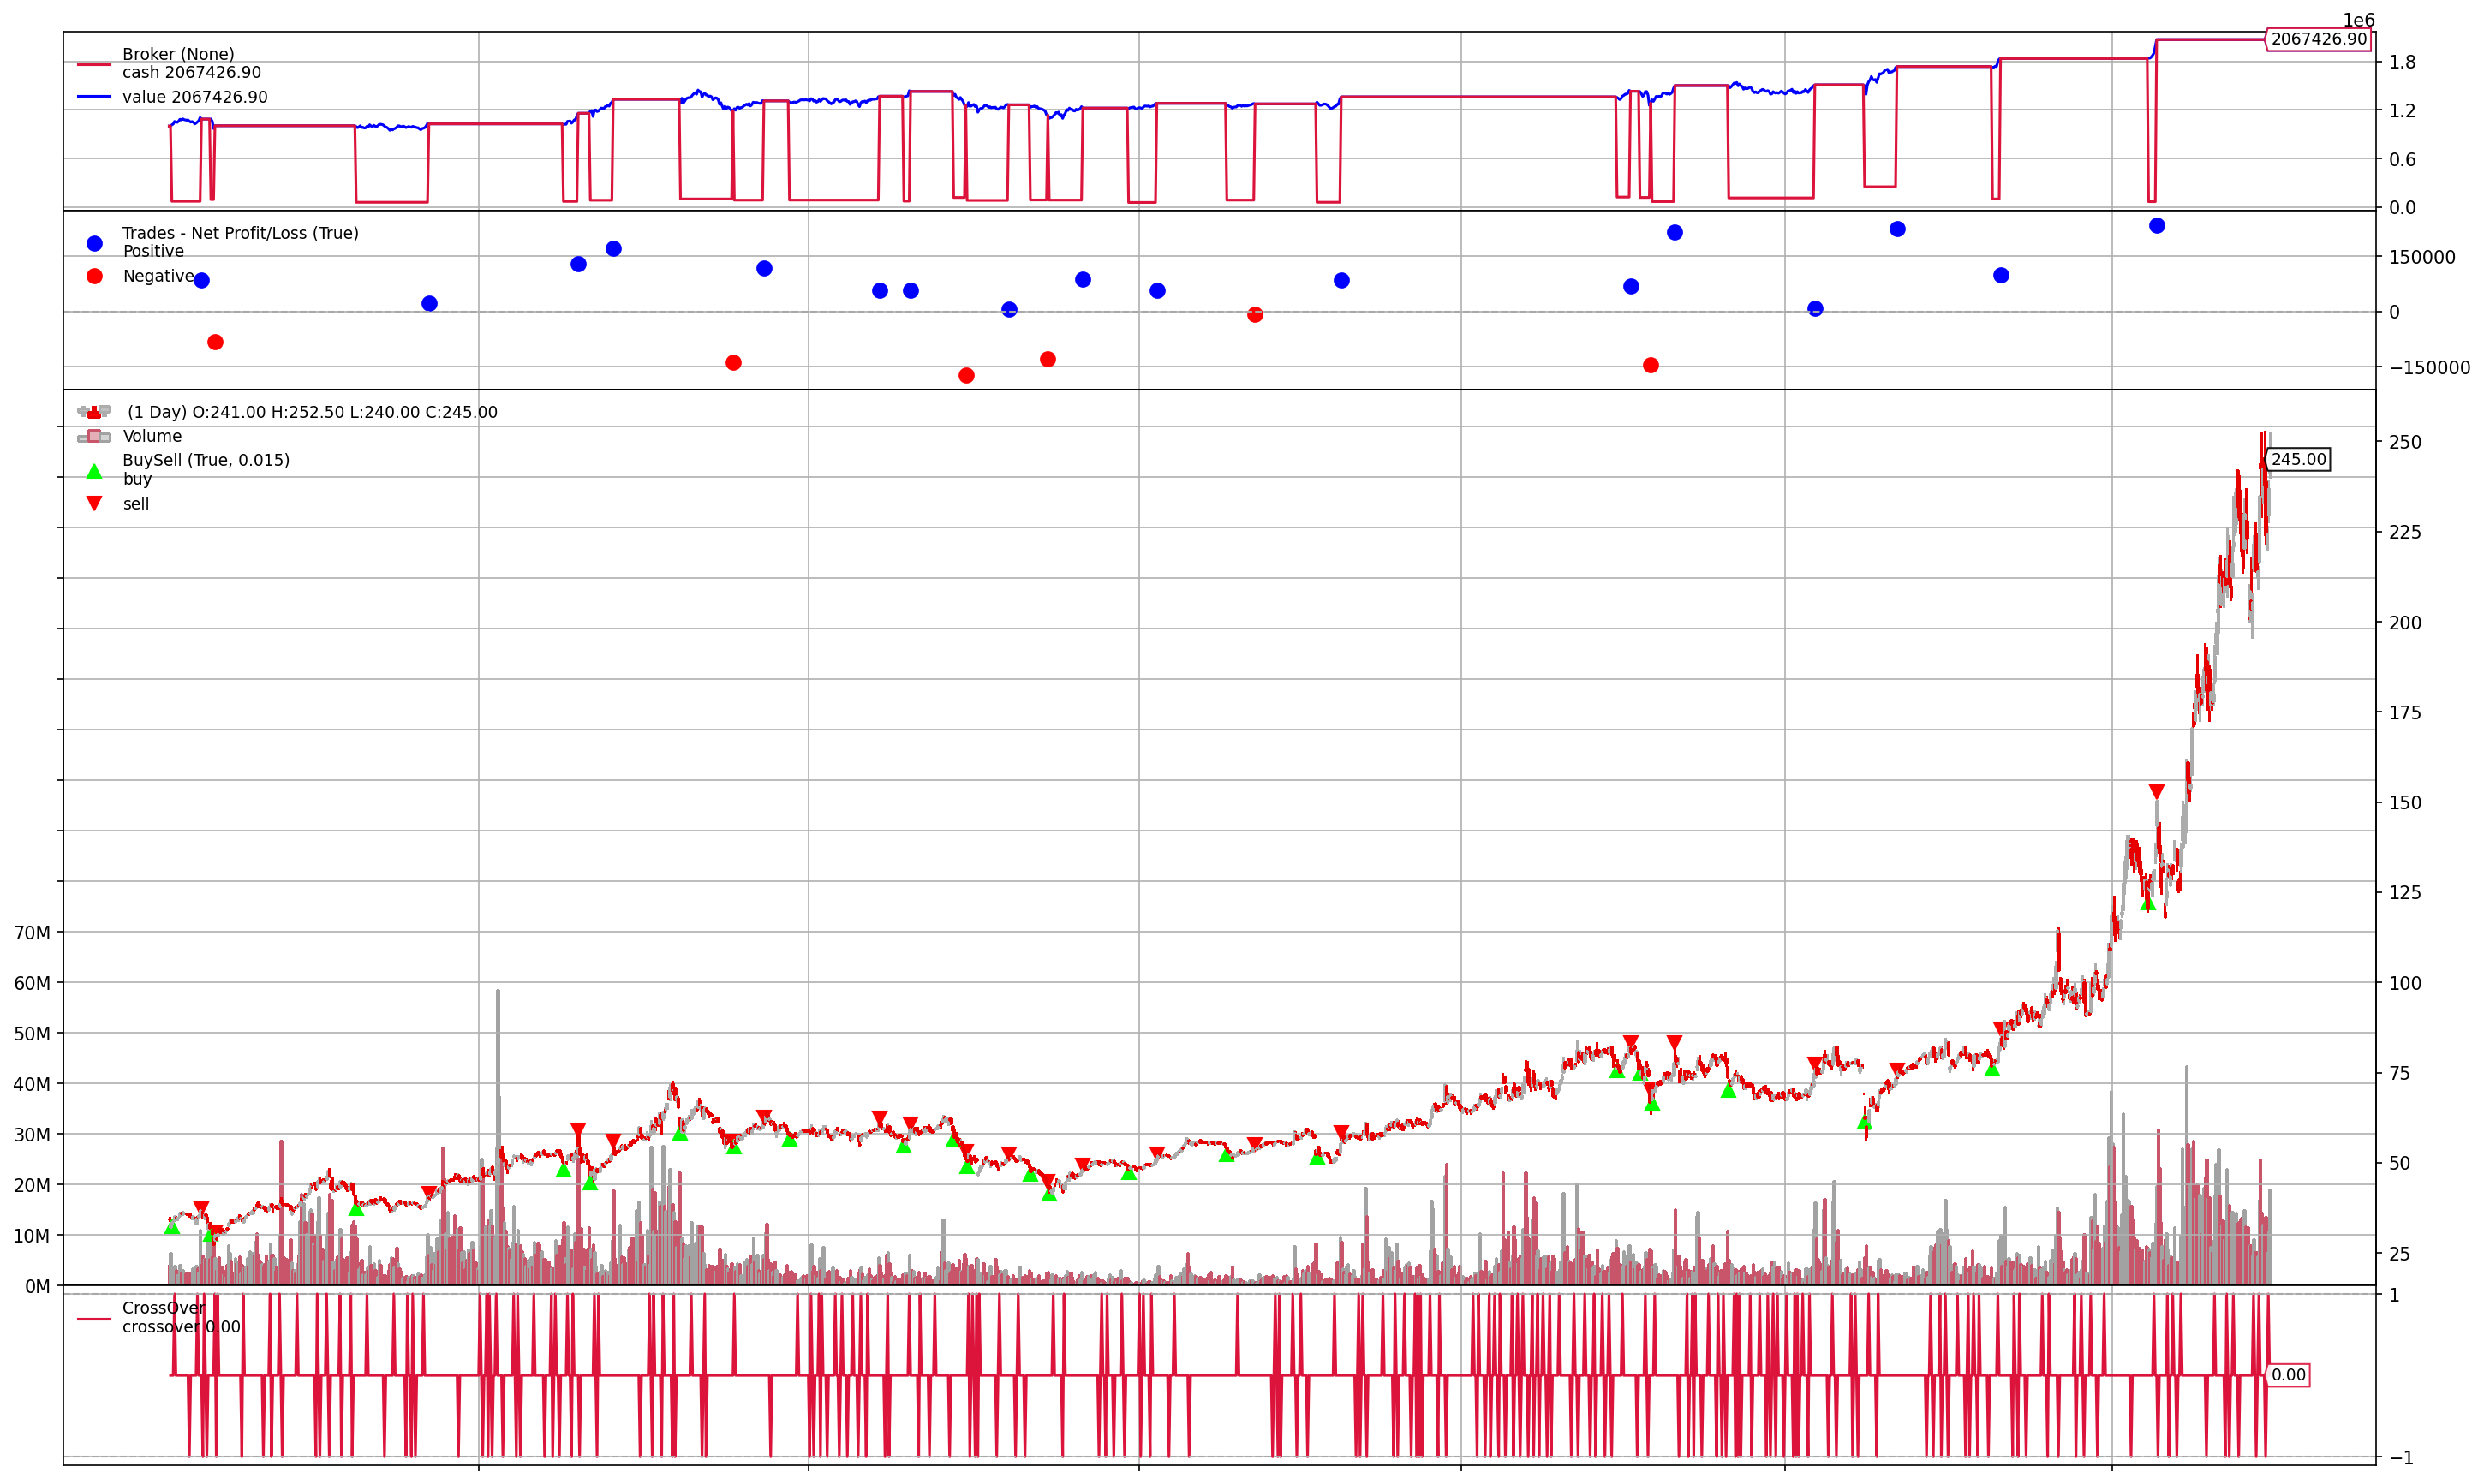


 回測標的：2382
最終資金：1,801,265.03 元
總報酬率：80.13 %
最大回撤 (MDD)：25.90 %
夏普比率(Sharpe)：0.51
總交易次數：25 次
勝率：68.00 %
賺賠比：0.90

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-02-04,買入,61.0,15000,915000.0,1303.88,0.0,1010696.12,1.07
1,2020-03-20,賣出,52.4,15000,786000.0,1120.05,2358.0,866218.07,-13.38
2,2020-03-24,買入,54.9,15000,823500.0,1173.49,0.0,901044.59,-9.90
3,2020-04-15,賣出,63.7,15000,955500.0,1361.59,2866.5,992816.50,-0.72
4,2020-06-15,買入,67.2,13000,873600.0,1244.88,0.0,988971.62,-1.10
5,2020-07-01,賣出,71.0,13000,923000.0,1315.28,2769.0,1036887.34,3.69
6,2020-08-04,買入,74.5,13000,968500.0,1380.11,0.0,1045907.23,4.59
7,2020-08-18,賣出,84.6,13000,1099800.0,1567.22,3299.4,1161940.62,16.19
8,2020-09-09,買入,74.1,14000,1037400.0,1478.29,0.0,1164662.32,16.47
9,2020-11-17,賣出,76.6,14000,1072400.0,1528.17,3217.2,1190716.95,19.07


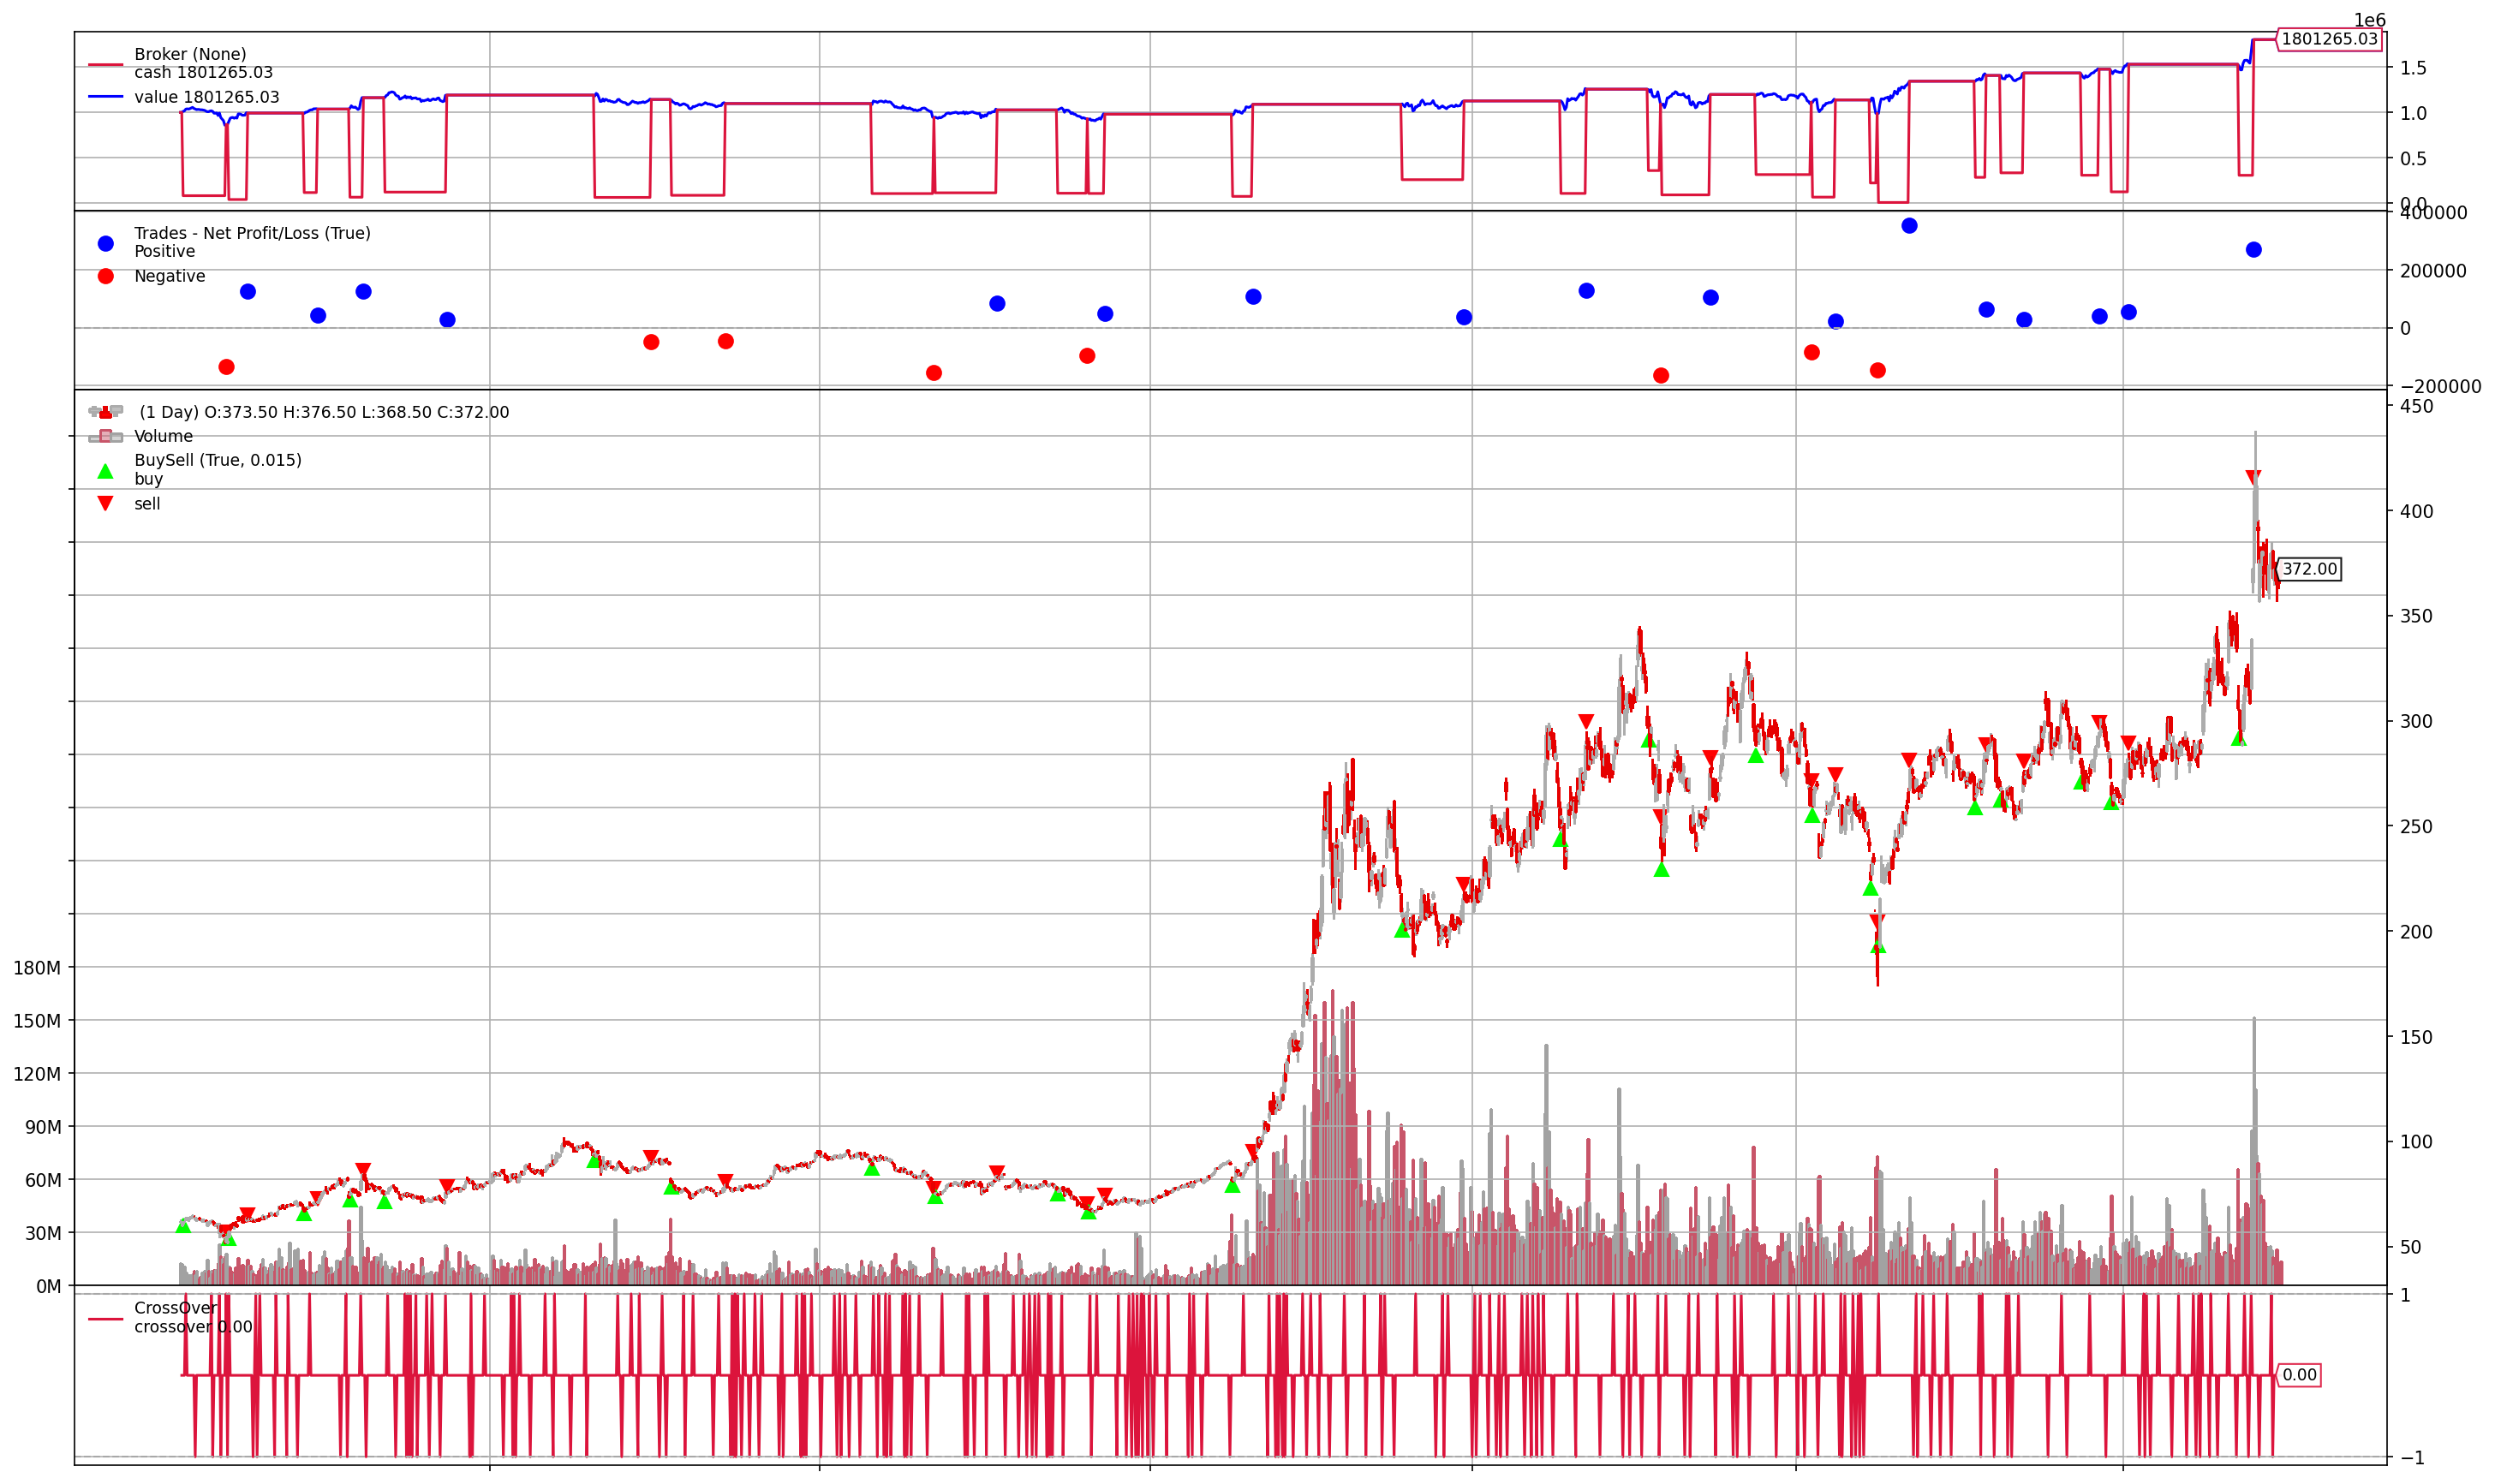


 回測標的：2317
最終資金：1,312,067.33 元
總報酬率：31.21 %
最大回撤 (MDD)：34.58 %
夏普比率(Sharpe)：0.25
總交易次數：28 次
勝率：64.29 %
賺賠比：0.80

=== 交易紀錄表 ===


,交易日期,買賣別,成交價,成交量(股),交易金額,手續費,證交稅,總資產,目前報酬率(%)
0,2020-02-04,買入,82.8,11000,910800.0,1297.89,0.0,992102.11,-0.79
1,2020-03-17,賣出,70.1,11000,771100.0,1098.82,2313.3,855589.99,-14.44
2,2020-03-18,買入,70.7,11000,777700.0,1108.22,0.0,846781.77,-15.32
3,2020-04-21,賣出,75.2,11000,827200.0,1178.76,2481.6,900321.41,-9.97
4,2020-07-24,買入,81.5,10000,815000.0,1161.38,0.0,884160.03,-11.58
5,2020-09-15,賣出,79.4,10000,794000.0,1131.45,2382.0,874646.58,-12.54
6,2020-09-24,買入,76.1,10000,761000.0,1084.42,0.0,862562.16,-13.74
7,2020-10-20,賣出,81.5,10000,815000.0,1161.38,2445.0,923955.78,-7.60
8,2021-05-04,買入,112.0,7000,784000.0,1117.20,0.0,898338.58,-10.17
9,2021-05-18,賣出,101.5,7000,710500.0,1012.46,2131.5,846194.62,-15.38


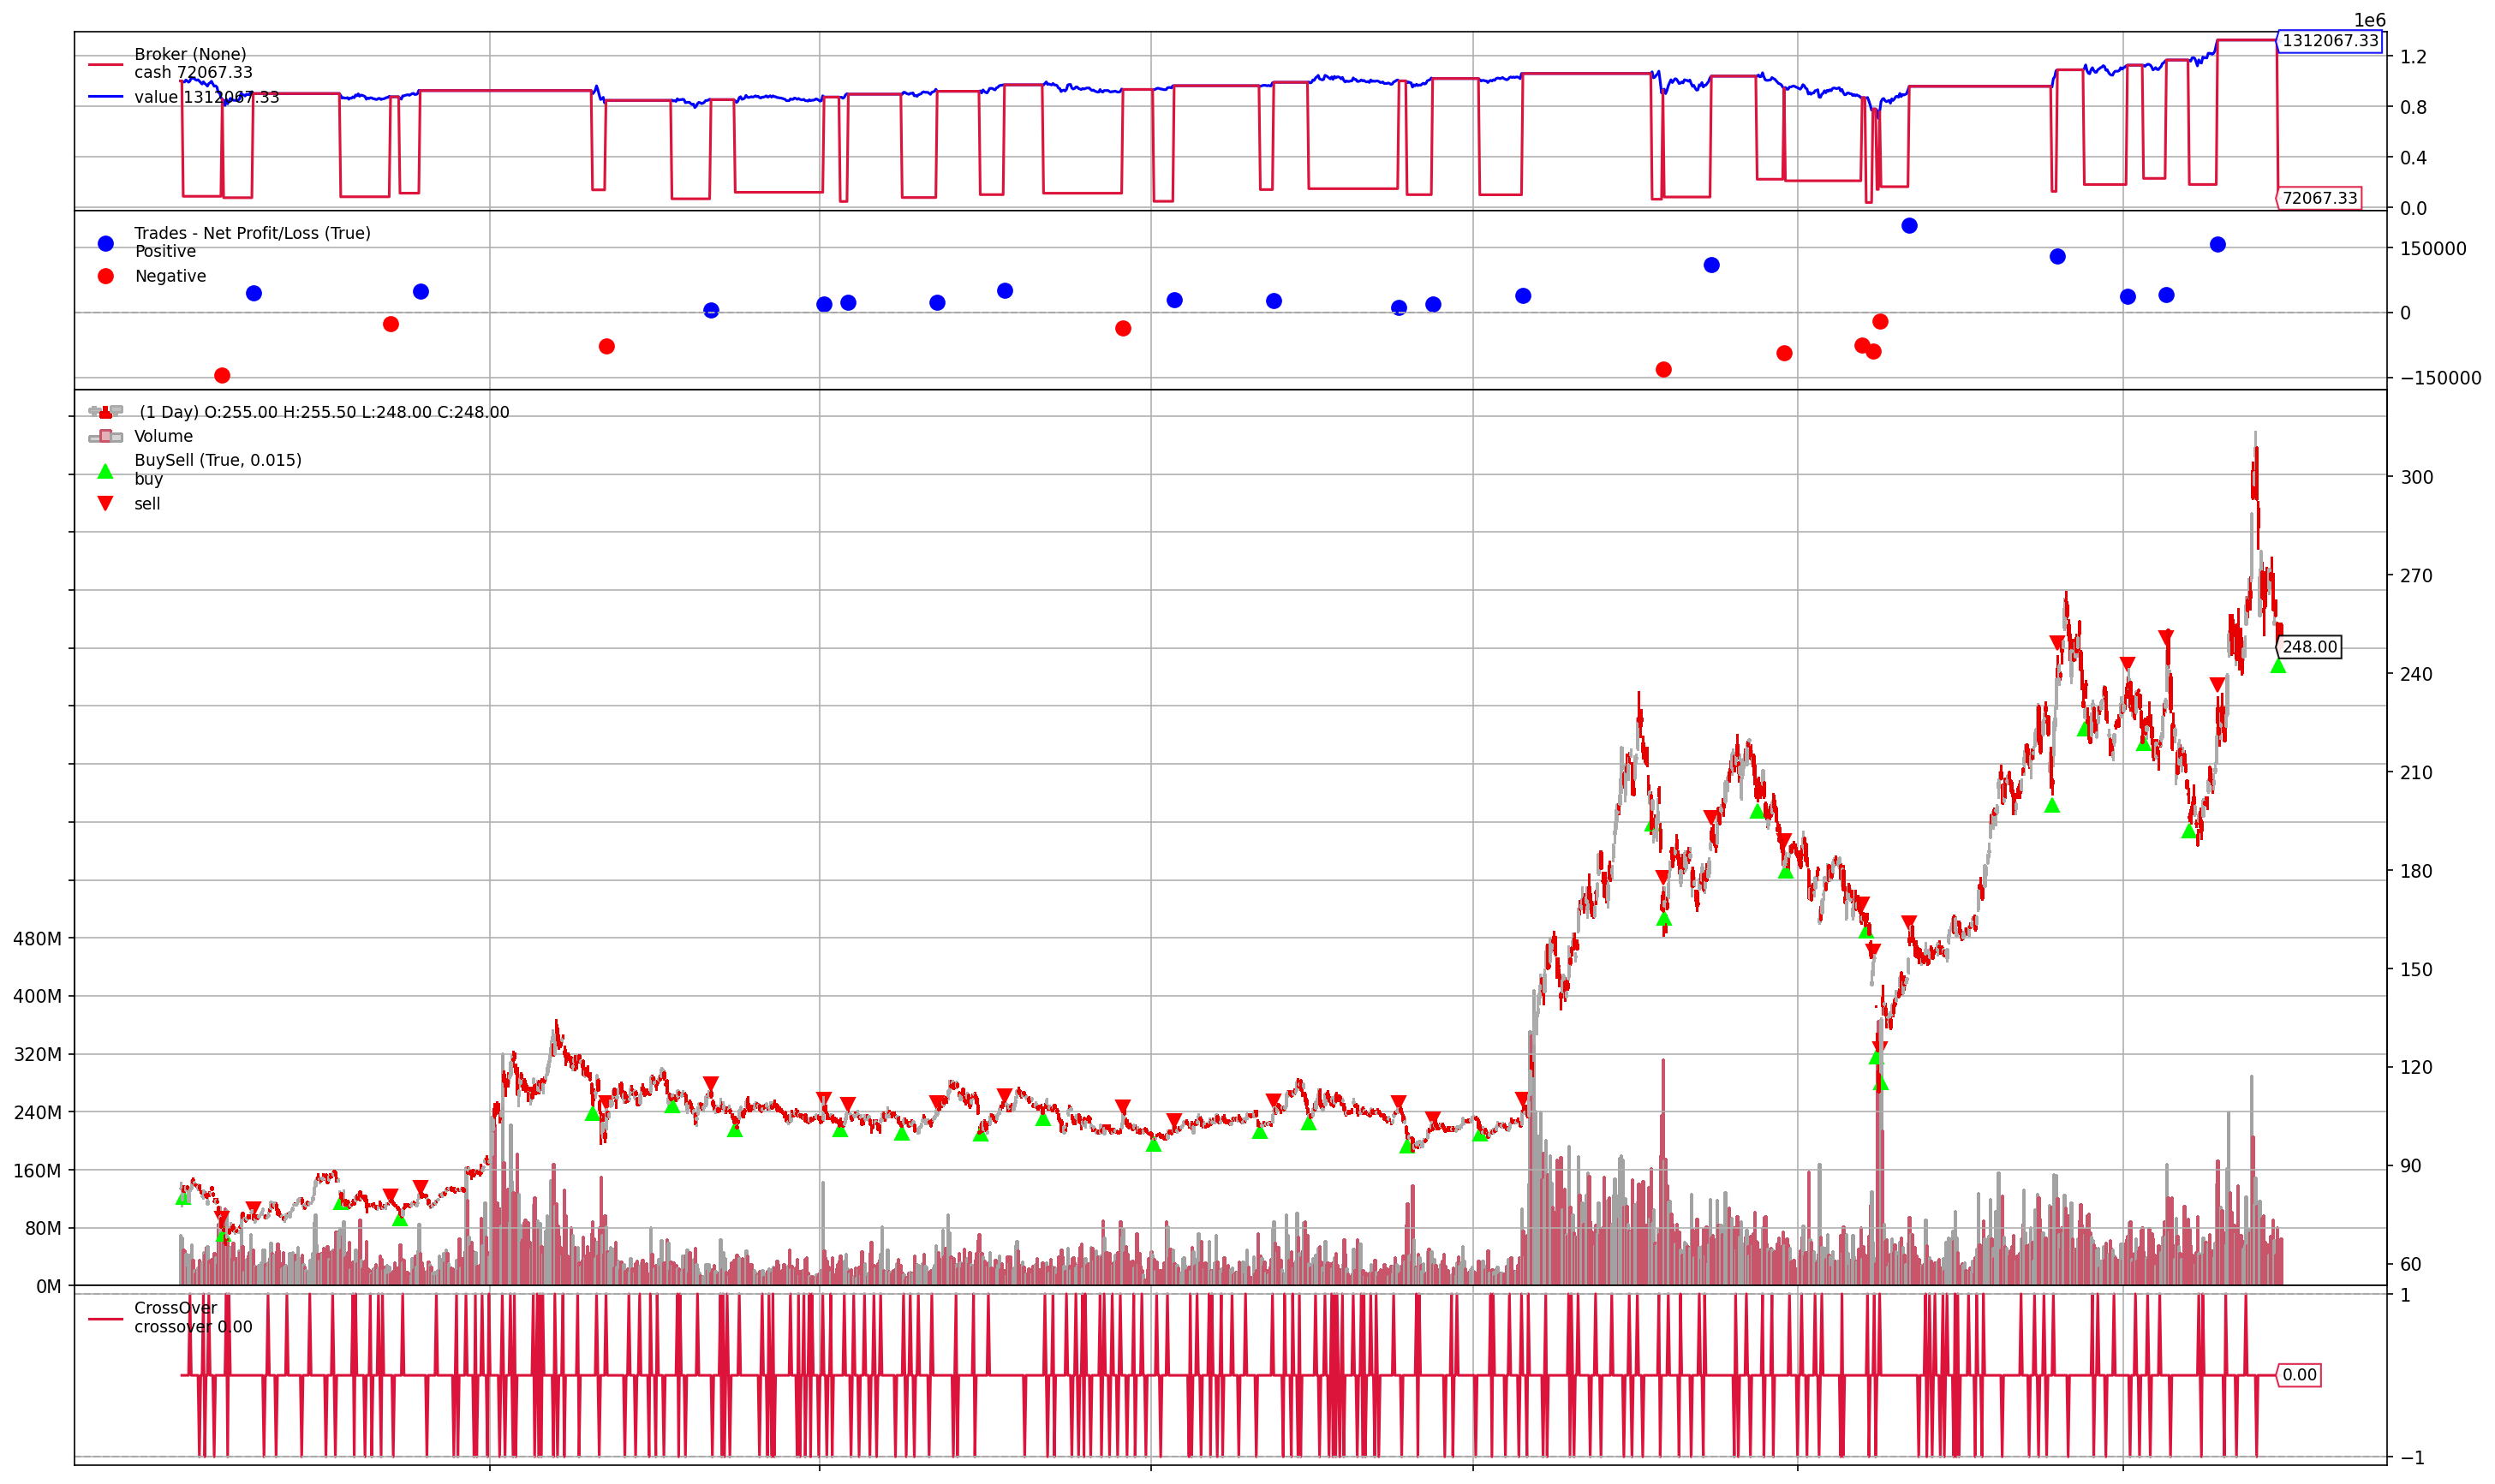


      所有股票績效總表


,標的,交易策略,最終資金 (元),總報酬率,最大回撤 (MDD),夏普比率,總交易次數,勝率,賺賠比
0,6257,RSI 超買／超賣,2067426.90,106.74,24.21,0.71,23,73.91,0.91
1,2382,RSI 超買／超賣,1801265.03,80.13,25.90,0.51,25,68.00,0.90
2,2313,RSI 超買／超賣,1628866.57,62.89,42.32,0.38,29,62.07,0.90
3,2317,RSI 超買／超賣,1312067.33,31.21,34.58,0.25,28,64.29,0.80
4,2330,RSI 超買／超賣,948512.13,-5.15,34.24,-0.08,25,64.00,0.52


In [39]:
import pandas as pd
import numpy as np
import backtrader as bt
from IPython.display import display
import matplotlib.pyplot as plt

class PandasData(bt.feeds.PandasData):
    lines = ('RSI_7', 'RSI_14')
    params = (
        ('datetime', None),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),
        ('RSI_7', 'RSI_7'),
        ('RSI_14', 'RSI_14'),
    )

class TaiwanStockCommission(bt.CommissionInfo):
    params = (
        ("commission", 0.001425),
        ("tax", 0.003),
    )
    def _getcommission(self, size, price, pseudoexec):
        value = abs(size) * price
        commission = value * self.p.commission
        if size < 0:
            commission += value * self.p.tax
        return commission

class AllInSizer(bt.Sizer):
    params = (("reserve", 0.05),("lot_size", 1000),)
    def _getsizing(self, comminfo, cash, data, isbuy):
        if isbuy:
            cash *= (1 - self.p.reserve)
            price = data.close[0]
            cost_per_share = price * (1 + comminfo.p.commission)
            shares = int(cash / cost_per_share)
            if shares <= 0:
              return 0

            whole_lot = (shares // self.p.lot_size) * self.p.lot_size
            if whole_lot >= self.p.lot_size:
              return whole_lot

            return shares

        return self.broker.getposition(data).size

class RSIStrategy(bt.Strategy):
    params = dict(stop_loss=0.10, rsi_low=30, rsi_high=70)

    def __init__(self):
        self.RSI_7 = self.data.RSI_7
        self.RSI_14 = self.data.RSI_14
        self.cross = bt.ind.CrossOver(self.RSI_7, self.RSI_14)
        self.order = None
        self.buyprice = None
        self.trades_history = []

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status == order.Completed:
            date = self.data.datetime.date(0)
            exec_price = order.executed.price
            exec_size = abs(order.executed.size)
            exec_value = exec_price * exec_size

            comminfo = order.comminfo
            commission = exec_value * comminfo.p.commission
            tax = (exec_value * comminfo.p.tax) if order.issell() else 0.0

            current_value = self.broker.getvalue()
            pnl_pct = (current_value / 1_000_000 - 1) * 100

            action = "買入" if order.isbuy() else "賣出"
            if order.isbuy():
                self.buyprice = exec_price

            self.trades_history.append({
                "交易日期": date,
                "買賣別": action,
                "成交價": round(exec_price, 2),
                "成交量(股)": exec_size,
                "交易金額": round(exec_value, 2),
                "手續費": round(commission, 2),
                "證交稅": round(tax, 2),
                "總資產": round(current_value, 2),
                "目前報酬率(%)": round(pnl_pct, 2)
            })
            # 關閉單筆印出以保持版面整潔，需要可取消註解
            # print(f"{date} {action} | 價格:{exec_price:.2f} | 成交量:{exec_size} | 手續費:{commission:.0f} | 證交稅:{tax:.0f}")

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            print(f"{self.data.datetime.date(0)} 交易失敗 : {order.getstatusname()}")

        self.order = None

    def next(self):
        if self.order:
            return
        if self.position:
            loss = (self.data.close[0] - self.buyprice) / self.buyprice
            if loss <= -self.p.stop_loss:
                # print(f"{self.data.datetime.date(0)}停損觸發")
                self.order = self.close()
                return
            if self.RSI_7[0] > self.p.rsi_high:
                # print(f"{self.data.datetime.date(0)} RSI高檔(K:{self.RSI_7[0]:.1f}, D:{self.RSI_14[0]:.1f})")
                self.order = self.close()
                return
        else:
            if self.RSI_7[0] < self.p.rsi_low:
            # if self.RSI_7[-1] < self.p.rsi_low and self.RSI_7[0] >= self.p.rsi_low:
                # print(f"{self.data.datetime.date(0)} RSI低檔(K:{self.RSI_7[0]:.1f}, D:{self.RSI_14[0]:.1f})")
                self.order = self.buy()

    def stop(self):
        if self.position:
            # print(f"回測結束，強制結算持股：{self.position.size}股")
            self.close()

# 執行回測
def run_backtest(ticker):
    print("\n" + "="*50)
    print(f" 回測標的：{ticker}")
    print("="*50)

    # 讀取資料
    try:
        df = pd.read_csv(f"{ticker}_Cal.csv")
    except FileNotFoundError:
        print(f"找不到檔案：{ticker}_Cal.csv，跳過此標的。")
        return

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    df_bt = df[['date', 'open', 'max', 'min', 'close', 'RSI_7', 'RSI_14', 'Trading_Volume']].copy()
    df_bt = df_bt.rename(columns={"max": "high", "min": "low", "Trading_Volume": "volume"})
    df_bt = df_bt.dropna().reset_index(drop=True)
    df_bt = df_bt.set_index("date")

    # Cerebro
    cerebro = bt.Cerebro()
    cerebro.addstrategy(RSIStrategy)
    cerebro.addsizer(AllInSizer, reserve=0.05)

    data = PandasData(dataname=df_bt)
    cerebro.adddata(data)
    cerebro.broker.setcash(1_000_000)

    comminfo = TaiwanStockCommission()
    cerebro.broker.addcommissioninfo(comminfo)

    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe', riskfreerate=0.015, annualize=True, timeframe=bt.TimeFrame.Days)
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

    # 執行回測
    results = cerebro.run()
    strat = results[0]

    # 整理表格
    df_trades = pd.DataFrame(strat.trades_history)
    final_val = cerebro.broker.getvalue()
    pnl_pct = (final_val / 1_000_000 - 1) * 100

    if strat.position:
        last_date = strat.data.datetime.date(0)
        pos_size = strat.position.size
        close_price = strat.data.close[0]
        unrealized_value = pos_size * close_price

        unrealized_row = pd.DataFrame([{
            "交易日期": last_date, "買賣別": "結算",
            "成交價": round(close_price, 2), "成交量(股)": pos_size,
            "交易金額": round(unrealized_value, 2), "手續費": 0.0, "證交稅": 0.0,
            "總資產": round(final_val, 2), "目前報酬率(%)": round(pnl_pct, 2)
        }])
        df_trades = pd.concat([df_trades, unrealized_row], ignore_index=True)

    # 輸出 CSV
    df_trades.to_csv(f'{ticker}_df_trades.csv', index=False)

    # 績效指標計算
    mdd = strat.analyzers.drawdown.get_analysis()['max']['drawdown']
    sharpe_info = strat.analyzers.sharpe.get_analysis()
    sharpe = sharpe_info.get('sharperatio', None)

    trade_pnls = []
    raw_trades = df_trades[df_trades['買賣別'] != '結算'].copy()
    buy_record = None
    for _, row in df_trades.iterrows():
        if row['買賣別'] == '買入':
            buy_record = row
        elif row['買賣別'] in ['賣出', '結算'] and buy_record is not None:
            cost = buy_record['交易金額'] + buy_record['手續費']
            revenue = row['交易金額'] - row['手續費'] - row['證交稅']
            pnl = revenue - cost
            trade_pnls.append(pnl)
            buy_record = None

    trade_pnls = np.array(trade_pnls)
    if len(trade_pnls) > 0:
        wins = trade_pnls[trade_pnls > 0]
        losses = trade_pnls[trade_pnls < 0]
        win_rate = (len(wins) / len(trade_pnls)) * 100
        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = abs(np.mean(losses)) if len(losses) > 0 else 0
        profit_factor = (avg_win / avg_loss) if avg_loss != 0 else np.nan
    else:
        win_rate = profit_factor = 0.0

    print(f"最終資金：{final_val:,.2f} 元")
    print(f"總報酬率：{pnl_pct:.2f} %")
    print(f"最大回撤 (MDD)：{mdd:.2f} %")
    print(f"夏普比率(Sharpe)：{sharpe:.2f}" if sharpe is not None else "夏普比率(Sharpe)：無法計算 (無交易)")
    print(f"總交易次數：{len(trade_pnls)} 次")
    print(f"勝率：{win_rate:.2f} %")
    print(f"賺賠比：{profit_factor:.2f}")

    print("\n=== 交易紀錄表 ===")
    display(df_trades)

    # 繪圖
    plt.rcParams['figure.figsize'] = [20, 12]
    plt.rcParams['figure.dpi'] = 150
    cerebro.plot(style="candlestick", iplot=False, heightp=0.5)
    plt.show()

    return {
        "標的": ticker,
        "交易策略": "RSI 超買／超賣", #　交易策略有變動的話需更改
        "最終資金 (元)": round(final_val, 2),
        "總報酬率": round(pnl_pct, 2),
        "最大回撤 (MDD)": round(mdd, 2),
        "夏普比率": round(sharpe, 2) if sharpe is not None else np.nan,
        "總交易次數": len(trade_pnls),
        "勝率": round(win_rate, 2),
        "賺賠比": round(profit_factor, 2) if not np.isnan(profit_factor) else np.nan}

performance_summary = []
# 標的清單
stock_list = ["2330", "2313", "6257", "2382", "2317"]

for stock_id in stock_list:
    # run_backtest(stock_id)
    result = run_backtest(stock_id)

    if result is not None:
      performance_summary.append(result)
df_summary = pd.DataFrame(performance_summary)

# 依照報酬率排序
df_summary = df_summary.sort_values(by="總報酬率", ascending=False).reset_index(drop=True)

print("\n==============================")
print("      所有股票績效總表")
print("==============================")

display(df_summary)

df_summary.to_csv("RSI_OBOS_Backtest_Performance.csv", index=False, encoding="utf-8-sig")